**SMOTE** বা **Synthetic Minority Over-sampling Technique** হলো মেশিন লার্নিংয়ের একটি অত্যন্ত জনপ্রিয় পদ্ধতি, যা মূলত **Imbalanced Dataset**-এর সমস্যা সমাধান করতে ব্যবহৃত হয়।

সহজ কথায়, যখন কোনো ডেটাসেটে একটি ক্লাস (Category) অনেক বেশি থাকে এবং অন্যটি খুব কম থাকে, তখন মডেলটি সঠিকভাবে শিখতে পারে না। SMOTE এই সমস্যার সমাধান করে।

---

### SMOTE কীভাবে কাজ করে?

SMOTE সাধারণত **Over-sampling** পদ্ধতিতে কাজ করে, তবে এটি সাধারণ ডুপ্লিকেট তৈরি না করে নতুন **Synthetic Data** তৈরি করে। এর ধাপগুলো নিচে দেওয়া হলো:

1.  **Selection:** প্রথমে Minority Class (যেটির সংখ্যা কম) থেকে একটি র‍্যান্ডম ডেটা পয়েন্ট সিলেক্ট করা হয়।
2.  **K-Nearest Neighbors (KNN):** ওই পয়েন্টটির সবচেয়ে কাছের প্রতিবেশীদের (Neighbors) খুঁজে বের করা হয়।
3.  **Difference calculation:** নির্বাচিত পয়েন্ট এবং তার প্রতিবেশীর মধ্যে দূরত্বের পার্থক্য বের করা হয়।
4.  **Synthetic Data Generation:** এই পার্থক্যের সাথে ০ থেকে ১-এর মধ্যে একটি র‍্যান্ডম নম্বর গুণ করে মূল পয়েন্ট এবং প্রতিবেশীর মাঝখানের কোনো একটি স্থানে একটি নতুন **Synthetic Point** বা ডামি ডেটা তৈরি করা হয়।



---

### SMOTE কেন ব্যবহার করবেন?

* **Prevents Overfitting:** সাধারণ Over-sampling-এ ডেটা ডুপ্লিকেট করা হয় বলে মডেল Overfit হতে পারে। SMOTE নতুন ডেটা তৈরি করে বলে এই ঝুঁকি কমে।
* **Better Generalization:** এটি মডেলকে Minority Class সম্পর্কে আরও ভালো ধারণা দেয়, ফলে মডেলটি বাস্তব ক্ষেত্রে সঠিক প্রেডিকশন করতে পারে।

---

### একটি বাস্তব উদাহরণ

ধরুন, আপনি একটি **Fraud Detection** মডেল তৈরি করছেন। আপনার কাছে ১০০০টি ট্রানজ্যাকশন ডেটা আছে যার মধ্যে ৯৯০টি **Normal** কিন্তু মাত্র ১০টি **Fraud**। 

এখানে মডেলটি সব ট্রানজ্যাকশনকেই "Normal" বলে প্রেডিক্ট করার চেষ্টা করবে। SMOTE ব্যবহার করে আপনি ওই ১০টি Fraud ডেটা থেকে কৃত্রিমভাবে আরও অনেকগুলো Fraud ডেটা তৈরি করতে পারেন, যাতে মডেলটি দুটি ক্লাসকেই সমান গুরুত্ব দেয়।

---

### SMOTE-এর কিছু সীমাবদ্ধতা

* **Noise generation:** যদি ডেটাসেটে অনেক বেশি 'Noise' থাকে, তবে SMOTE ভুলবশত সেই নয়েজকেও বাড়িয়ে দিতে পারে।
* **High-dimensional data:** খুব জটিল বা হাই-ডাইমেনশনাল ডেটার ক্ষেত্রে এটি সবসময় কার্যকর নাও হতে পারে।


In [1]:
from sklearn.datasets import make_classification

In [3]:
x,y = make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.90],random_state=12)

## n_samples: আপনি মোট কতগুলো ডেটা পয়েন্ট বা রো (Row) চান। (Default: 100)
##n_features: মোট কতগুলো কলাম বা বৈশিষ্ট্য (Features) থাকবে।

##n_informative: এর মধ্যে কতগুলো ফিচার আসলে প্রেডিকশন করতে সরাসরি সাহায্য করবে।

##n_redundant: কতগুলো ফিচার অপ্রয়োজনীয় বা অন্য ফিচারের লিনিয়ার কম্বিনেশন হিসেবে থাকবে।

##n_classes: আপনি কয়টি ক্যাটাগরি বা ক্লাস চান (যেমন: ০ এবং ১ হলে ২)।

##weights: এটি দিয়ে আপনি ক্লাসের অনুপাত (Ratio) ঠিক করতে পারেন (ইমব্যালেন্স ডেটা তৈরির জন্য)।

##random_state: যাতে প্রতিবার কোডটি রান করলে একই রকম র‍্যান্ডম ডেটা জেনারেট হয়।##

In [5]:
import pandas as pd
df1 = pd.DataFrame(x,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns = ['target'])
final_df = pd.concat([df1,df2],axis=1)
final_df

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0
...,...,...,...
995,-0.712495,-0.880452,0
996,-2.625830,-2.827891,0
997,-1.326439,-1.815178,0
998,-0.833486,-0.514647,0


In [6]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

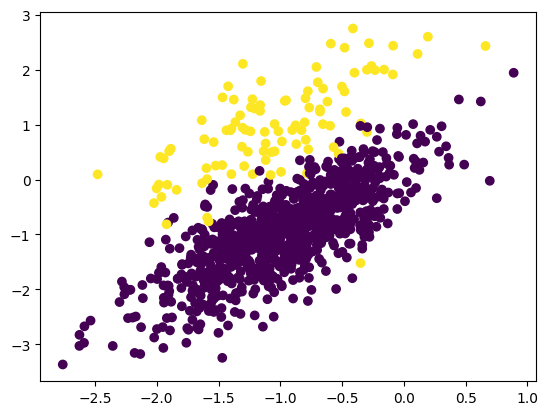

In [7]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [ ]:
%pip install imblearn
## Imbalance learn libraray

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)

   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 3.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/12.3 MB 4.0 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.3 MB 4.3 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.3 MB 3.8 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.3 MB 3.3 MB/s eta 0:00:03
   ----------- ---------------------------- 3.7/12.3 MB 3.0 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.3 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 4.5/12.3 MB 2.7 MB/s eta 0:00:03
   ----------------- ---------------------- 5.2/12.3 MB 2.7 MB/s eta 0:00:03
   ----------------- ---------------------- 5.5/12.3 


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [11]:
from imblearn.over_sampling import SMOTE

In [12]:
oversample = SMOTE()
x,y = oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [13]:
x.shape

(1800, 2)

In [14]:
y.shape

(1800,)

In [15]:
y==0

0        True
1        True
2        True
3       False
4        True
        ...  
1795    False
1796    False
1797    False
1798    False
1799    False
Name: target, Length: 1800, dtype: bool

In [16]:
y[y==0]

0      0
1      0
2      0
4      0
5      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: target, Length: 900, dtype: int64

In [17]:
len(y[y==0])

900

In [18]:
len(y[y==1])

900

In [23]:
df1 = pd.DataFrame(x,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
oversample_df = pd.concat([df1,df2],axis=1)

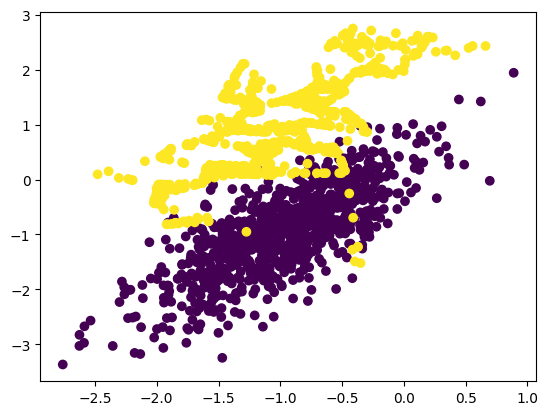

In [25]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c = oversample_df['target'])

In [27]:
oversample_df['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64